# Applied Statistics: PyMC

Submitting: Gilad Mizrahi

## 0 - EDA

In [42]:
import arviz as az
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import statsmodels.api as sm
from matplotlib import pyplot as plt
from scipy import stats

az.rcParams["stats.round_to"] = 2
az.style.use("arviz-variat")


df = sm.datasets.get_rdataset("SAT", "mosaicData").data

REGIONS = {
    "Alabama": "East South Central",
    "Alaska": "Pacific",
    "Arizona": "Mountain",
    "Arkansas": "West South Central",
    "California": "Pacific",
    "Colorado": "Mountain",
    "Connecticut": "New England",
    "Delaware": "South Atlantic",
    "Florida": "South Atlantic",
    "Georgia": "South Atlantic",
    "Hawaii": "Pacific",
    "Idaho": "Mountain",
    "Illinois": "East North Central",
    "Indiana": "East North Central",
    "Iowa": "West North Central",
    "Kansas": "West North Central",
    "Kentucky": "East South Central",
    "Louisiana": "West South Central",
    "Maine": "New England",
    "Maryland": "South Atlantic",
    "Massachusetts": "New England",
    "Michigan": "East North Central",
    "Minnesota": "West North Central",
    "Mississippi": "East South Central",
    "Missouri": "West North Central",
    "Montana": "Mountain",
    "Nebraska": "West North Central",
    "Nevada": "Mountain",
    "New Hampshire": "New England",
    "New Jersey": "Middle Atlantic",
    "New Mexico": "Mountain",
    "New York": "Middle Atlantic",
    "North Carolina": "South Atlantic",
    "North Dakota": "West North Central",
    "Ohio": "East North Central",
    "Oklahoma": "West South Central",
    "Oregon": "Pacific",
    "Pennsylvania": "Middle Atlantic",
    "Rhode Island": "New England",
    "South Carolina": "South Atlantic",
    "South Dakota": "West North Central",
    "Tennessee": "East South Central",
    "Texas": "West South Central",
    "Utah": "Mountain",
    "Vermont": "New England",
    "Virginia": "South Atlantic",
    "Washington": "Pacific",
    "West Virginia": "South Atlantic",
    "Wisconsin": "East North Central",
    "Wyoming": "Mountain",
}

df.insert(1, "region", pd.Categorical(df["state"].map(REGIONS)))
df.head()

,state,region,expend,ratio,salary,frac,verbal,math,sat
0,Alabama,East South Central,4.405,17.2,31.144,8,491,538,1029
1,Alaska,Pacific,8.963,17.6,47.951,47,445,489,934
2,Arizona,Mountain,4.778,19.3,32.175,27,448,496,944
3,Arkansas,West South Central,4.459,17.1,28.934,6,482,523,1005
4,California,Pacific,4.992,24.0,41.078,45,417,485,902


In [43]:
df["region"].value_counts()

region
Mountain              8
South Atlantic        8
West North Central    7
New England           6
East North Central    5
Pacific               5
East South Central    4
West South Central    4
Middle Atlantic       3
Name: count, dtype: int64

In [44]:
df.describe()

,expend,ratio,salary,frac,verbal,math,sat
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,5.905260,16.858000,34.828920,35.240000,457.140000,508.780000,965.920000
std,1.362807,2.266355,5.941265,26.762417,35.175948,40.204726,74.820558
min,3.656000,13.800000,25.994000,4.000000,401.000000,443.000000,844.000000
25%,4.881750,15.225000,30.977500,9.000000,427.250000,474.750000,897.250000
50%,5.767500,16.600000,33.287500,28.000000,448.000000,497.500000,945.500000
75%,6.434000,17.575000,38.545750,63.000000,490.250000,539.500000,1032.000000
max,9.774000,24.300000,50.045000,81.000000,516.000000,592.000000,1107.000000


**AI**,
* What is the SAT exam in one sentence?
* What are the possible exam scores? Give a percentile table.



| Variable | Description                                                                                  |
|----------|----------------------------------------------------------------------------------------------|
| state    | a factor with names of each state                                                            |
| expend   | expenditure per pupil in average daily attendance in public elementary and secondary schools |
| ratio    | average pupil/teacher ratio in public elementary and secondary schools                       |
| salary   | estimated average annual salary of teachers in public elementary and secondary schools       |
| frac     | percentage of all eligible students taking the SAT                                           |
| verbal   | average verbal SAT score                                                                     |
| math     | average math SAT score                                                                       |
| sat      | average total SAT score                                                                      |

/home/unique/Documents/applied-stats-project/.venv/lib/python3.14/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


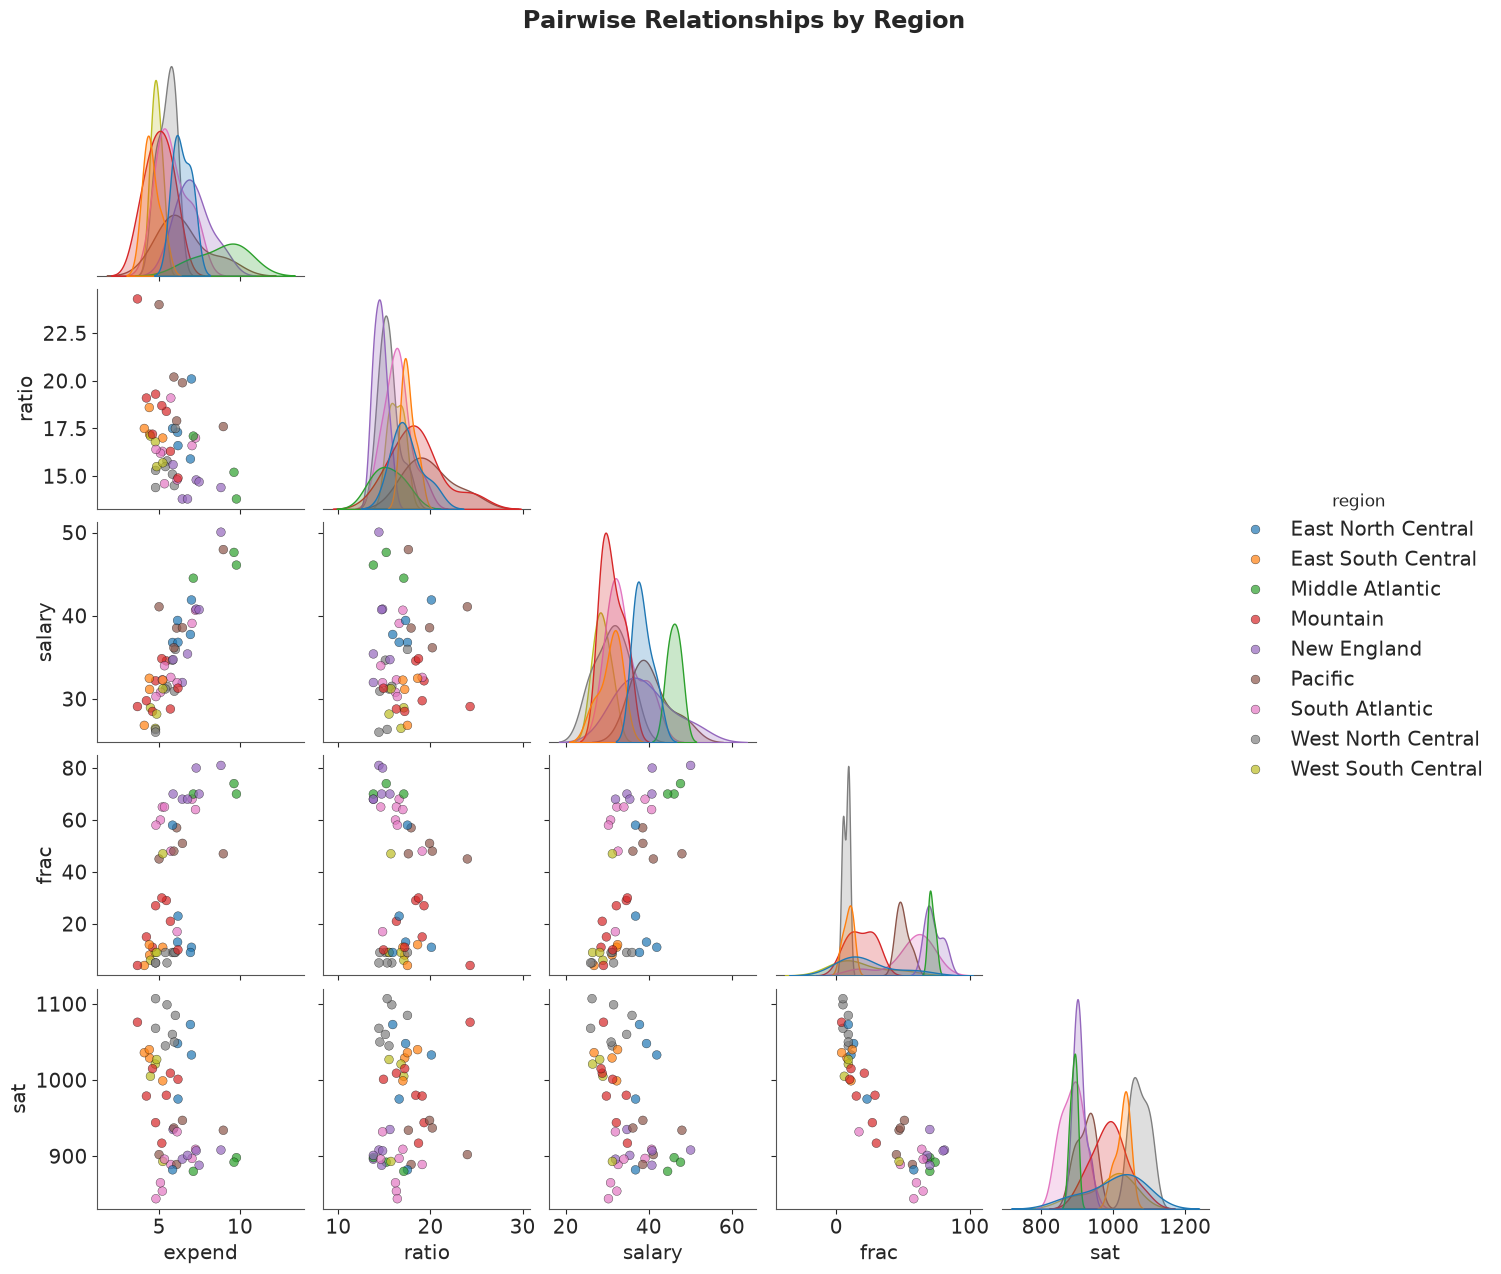

In [45]:
sns.pairplot(
    df.drop(columns=["verbal", "math"]),
    hue="region",
    palette="tab10",
    plot_kws={"alpha": 0.7, "s": 40, "edgecolor": "black", "linewidth": 0.3},
    diag_kind="kde",
    corner=True
)

plt.suptitle("Pairwise Relationships by Region", y=1.02)
plt.show()

### Simpson's Paradox?

/tmp/ipykernel_27869/2335787596.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


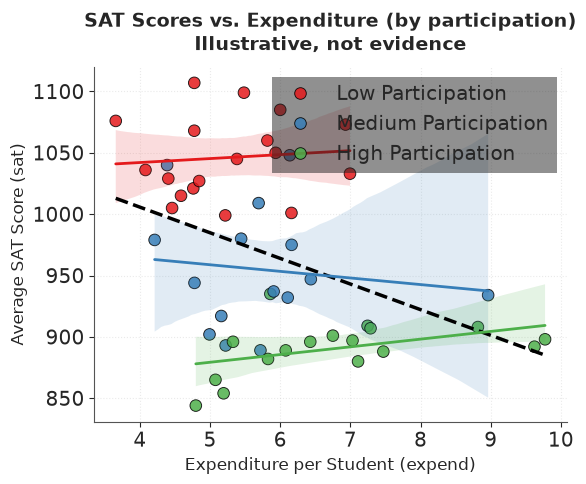

In [46]:
tiers = ["Low Participation", "Medium Participation", "High Participation"]

df["frac_tier"] = pd.qcut(df["frac"], q=3, labels=tiers)

# 1. Scatter points
sns.scatterplot(
    data=df,
    x="expend",
    y="sat",
    hue="frac_tier",
    palette="Set1",
    s=70,
    edgecolor="black",
    alpha=0.85,
)

# 2. Overall Naive Trend (No CI clutter)
sns.regplot(
    data=df,
    x="expend",
    y="sat",
    scatter=False,
    ci=None,
    line_kws={
        "linestyle": "--",
        "color": "black",
        "linewidth": 2.5,
        "label": "Pooled Trend (Naive)",
    },
)

# 3. Stratified Trends
colors = sns.color_palette("Set1", 3)

for tier, color in zip(tiers, colors):
    sns.regplot(
        data=df[df["frac_tier"] == tier],
        x="expend",
        y="sat",
        scatter=False,
        line_kws={"color": color, "linewidth": 2, "label": f"{tier} Trend"},
    )

plt.title(
    "SAT Scores vs. Expenditure (by participation)\nIllustrative, not evidence",
    fontsize=14,
    pad=12,
)
plt.xlabel("Expenditure per Student (expend)", fontsize=12)
plt.ylabel("Average SAT Score (sat)", fontsize=12)
plt.legend(frameon=True, facecolor="#222222", edgecolor="none")
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

**AI**,

* Can Simpson's paradox occur on a confounding variable that is not grouped/clustered?
* Show me the equation to when it actually happens

## 1 - Regression: Frequentist vs Bayesian

Frequentist: use OLS...

In [47]:
# Naive: sat ~ expend only
naive = sm.OLS(df["sat"], sm.add_constant(df[["expend"]])).fit()

# Adjusted: sat ~ expend + frac
adjusted = sm.OLS(df["sat"], sm.add_constant(df[["expend", "frac"]])).fit()

print("=== Naive OLS ===")
print(naive.summary())
print("\n=== Adjusted OLS ===")
print(adjusted.summary())

=== Naive OLS ===
                            OLS Regression Results                            
Dep. Variable:                    sat   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     8.128
Date:                Thu, 17 Sep 2026   Prob (F-statistic):            0.00641
Time:                        19:23:34   Log-Likelihood:                -282.29
No. Observations:                  50   AIC:                             568.6
Df Residuals:                      48   BIC:                             572.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1089.2937     44.390  

In [48]:
# Bootstrap CI for expend coefficient
n_boot = 5000
boot_coefs = np.empty(n_boot)
rng = np.random.default_rng(42)

for i in range(n_boot):
    sample = df.sample(n=len(df), replace=True, random_state=rng.integers(1e9))
    X_boot = sm.add_constant(sample[["expend", "frac"]])
    boot_model = sm.OLS(sample["sat"], X_boot).fit()
    boot_coefs[i] = boot_model.params["expend"]

boot_ci = np.percentile(boot_coefs, [2.5, 97.5])
print(f"Bootstrap 95% CI for expend: [{boot_ci[0]:.3f}, {boot_ci[1]:.3f}]")

Bootstrap 95% CI for expend: [4.932, 21.326]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_expend, beta_frac, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


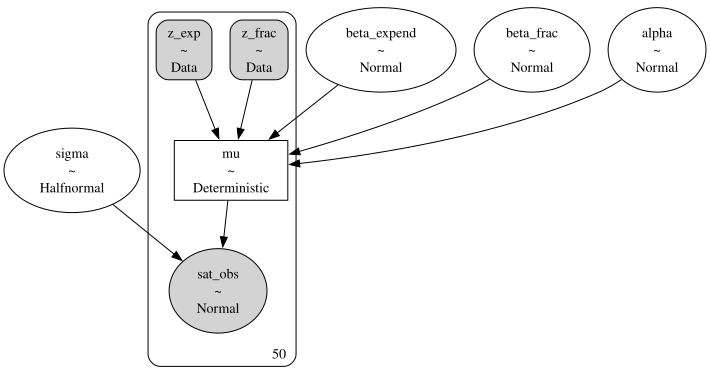

In [49]:
# Standardize predictors for better sampling
df["expend_z"] = (df["expend"] - df["expend"].mean()) / df["expend"].std()
df["frac_z"] = (df["frac"] - df["frac"].mean()) / df["frac"].std()

with pm.Model() as bayes_reg:
    # Priors
    alpha = pm.Normal("alpha", mu=df["sat"].mean(), sigma=50)
    beta_expend = pm.Normal("beta_expend", mu=0, sigma=50)
    beta_frac = pm.Normal("beta_frac", mu=0, sigma=50)
    sigma = pm.HalfNormal("sigma", sigma=df["sat"].std())
    
    # Linear model
    z_exp = pm.Data("z_exp", df["expend_z"].values)
    z_frac = pm.Data("z_frac", df["frac_z"].values)

    mu = pm.Deterministic("mu", alpha + beta_expend * z_exp + beta_frac * z_frac)
    
    # Likelihood
    sat_obs = pm.Normal("sat_obs", mu=mu, sigma=sigma, observed=df["sat"].values)
    
    idata_reg = pm.sample(2000, tune=1000, target_accept=0.9)

pm.model_to_graphviz(bayes_reg)

**AI**,

* How should we choose priors for a Bayesian regression? What happens if we choose priors that are too informative or too diffuse? What is a weakly informative prior and why is it recommended

In [50]:
az.summary(idata_reg, var_names=["alpha", "beta_expend", "beta_frac", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,965.8,4.8,958.27,973.48,7462,5696,1.00,0.06,0.06
beta_expend,15.9,5.9,6.48,25.13,7005,5835,1.00,0.07,0.07
beta_frac,-75.1,5.9,-84.4,-65.53,6865,5888,1.00,0.07,0.07
sigma,33.31,3.54,28.2,39.27,6766,5937,1.00,0.04,0.04


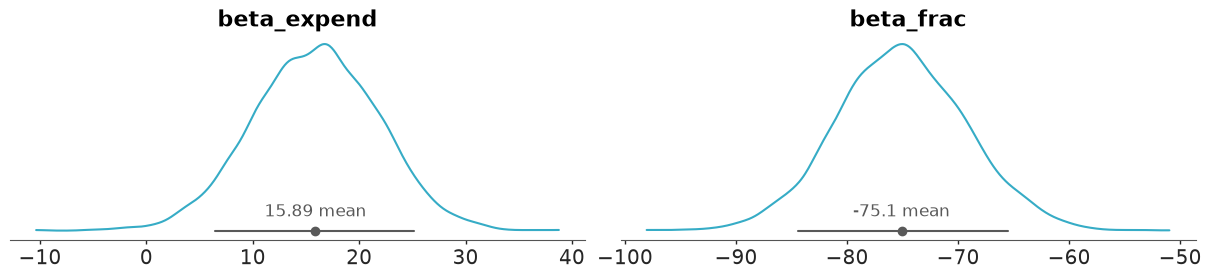

In [51]:
az.plot_dist(idata_reg, var_names=["beta_expend", "beta_frac"])

Difference?

/tmp/ipykernel_27869/2378579851.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


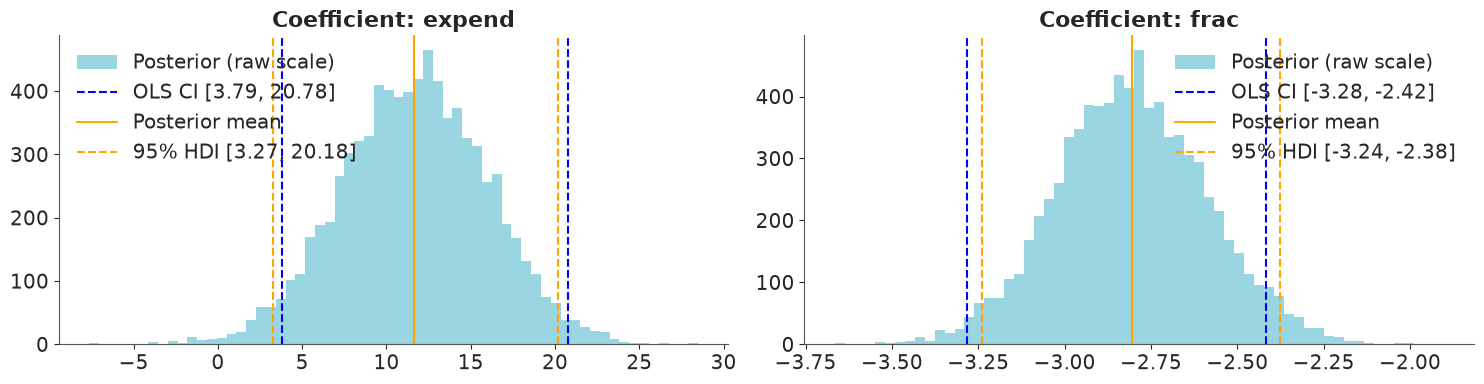

/tmp/ipykernel_27869/2378579851.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 600x500 with 0 Axes>

In [52]:
# Side-by-side: Bayesian posterior vs OLS CI
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Model was fit on z-scored predictors with RAW sat as outcome,
# so beta_std = "sat points per 1 SD of x"  ->  beta_raw = beta_std / sd(x)
scale = {"expend": df["expend"].std(), "frac": df["frac"].std()}

for ax, param_name, ols_name in zip(
    axes, ["beta_expend", "beta_frac"], ["expend", "frac"]
):
    posterior = idata_reg.posterior[param_name].values.flatten() / scale[ols_name]
    hdi = az.hdi(posterior, prob=0.95) 

    ols_ci = adjusted.conf_int().loc[ols_name]

    ax.hist(posterior, bins="auto", alpha=0.5, label="Posterior (raw scale)")
    ax.axvline(ols_ci[0], color="blue", linestyle="--",
               label=f"OLS CI [{ols_ci[0]:.2f}, {ols_ci[1]:.2f}]")
    ax.axvline(ols_ci[1], color="blue", linestyle="--")
    ax.axvline(posterior.mean(), color="orange", linestyle="-", label="Posterior mean")
    ax.axvline(hdi[0], color="orange", linestyle="--",
               label=f"95% HDI [{hdi[0]:.2f}, {hdi[1]:.2f}]")
    ax.axvline(hdi[1], color="orange", linestyle="--")
    ax.set_title(f"Coefficient: {ols_name}")
    ax.legend()

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

**AI**,

* What's the difference between HDI and CI?
* Compare the Bayesian posterior intervals with the frequentist bootstrap/OLS confidence intervals for the expenditure coefficient. Are they similar? If not, why might they differ? What does the Bayesian approach give us that the frequentist bootstrap does not


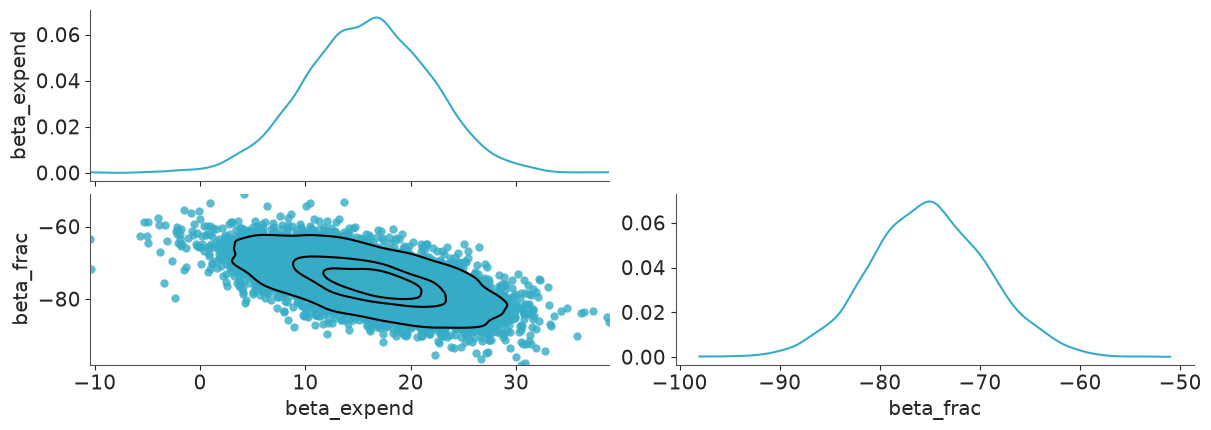

In [53]:
az.plot_pair(idata_reg, var_names=["beta_expend", "beta_frac"], marginal_kind="kde",
             visuals={"contourf": True,
                      "contour": {"color":"black"},
                      "scatter": {
                          "alpha": 0.8
                      }})

### Hypothesis Testing

Frequentist approach: test hypothesis and p-values

In [ ]:
# From the adjusted OLS
print("Frequentist p-values:")
print(adjusted.pvalues)
print()
print("95% CIs:")
print(adjusted.conf_int())

Frequentist p-values:
const     1.579349e-40
expend    5.529458e-03
frac      1.729825e-17
dtype: float64

95% CIs:
                 0            1
const   949.908859  1037.754459
expend    3.788291    20.784746
frac     -3.283679    -2.418179


**AI**,

* How does statsmodels compute the CI and p-values of the OLS coefficients?

Bayesian: BF, HDI

Sampling: [alpha, beta_expend, beta_frac, sat_obs, sigma]


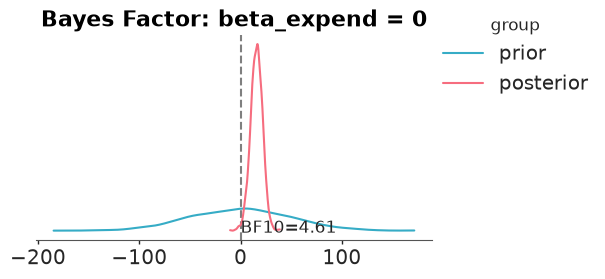

In [92]:
with bayes_reg:
    prior_idata = pm.sample_prior_predictive(draws=4000)
    idata_reg.update(prior_idata)


# Bayes factor for the slope of expend
# Test H0: beta_expend = 0 vs H1: beta_expend != 0
bf_result = az.plot_bf(idata_reg, var_names=["beta_expend"], ref_val=0)
plt.title("Bayes Factor: beta_expend = 0")
plt.show()

**AI**,

* What is a Bayes factor and how does it differ from a p-value? What does the BF10 value mean? Give a chart of value <-> strength
* What are the limitations of the Savage-Dickey ratio method for computing Bayes factors?
* Read my BF plot, what can we understand?

### Posterior Predictive

Sampling: [sat_obs]


Output()

/tmp/ipykernel_27869/3561989439.py:2: UserWarning: groups {'posterior_predictive'} already exist in the DataTree and will be overwritten. To avoid this, set extend_inferencedata=False.
  pm.sample_posterior_predictive(idata_reg, extend_inferencedata=True)


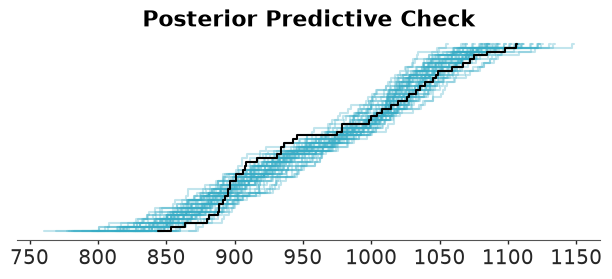

In [95]:
with bayes_reg:
    pm.sample_posterior_predictive(idata_reg, extend_inferencedata=True)

az.plot_ppc_dist(idata_reg)
plt.title("Posterior Predictive Check")
plt.show()

**AI**,

* What is a posterior predictive check? How is it useful for model evaluation?
* How do we read this plot? What would a bad posterior predictive check look like?

/tmp/ipykernel_27869/1950161031.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


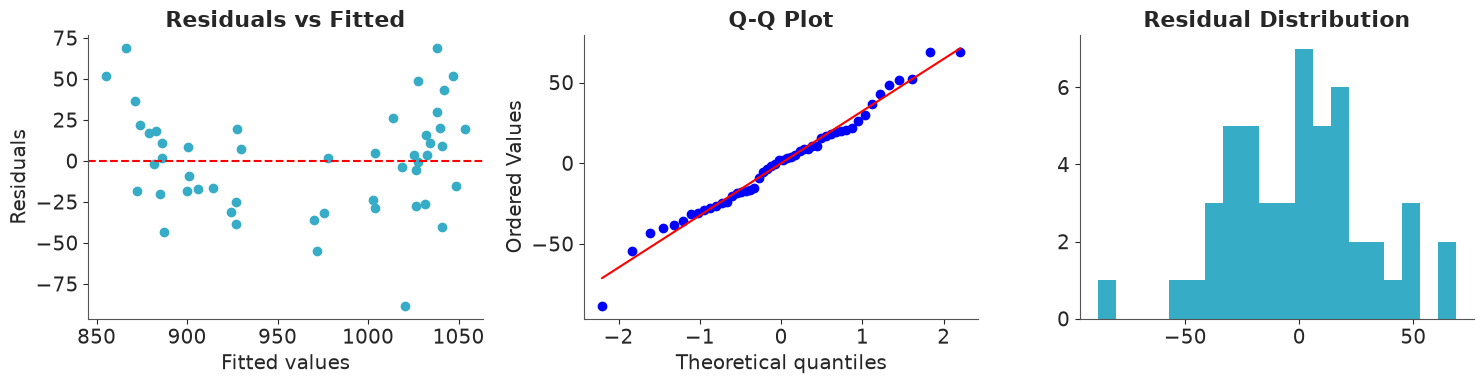

In [96]:
# Frequentist equivalent: residual analysis
residuals = adjusted.resid
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(adjusted.fittedvalues, residuals)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

axes[2].hist(residuals, bins=20)
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

**AI**,

* Explain the meaning of a Q-Q plot. How does it differ from a standard P-P plot?
* Compare the Bayesian posterior predictive check with the frequentist residual analysis. What does each tell us? What are the limitations of each approach?

## 2 - Group Means: Frequentist vs Bayesian

In [54]:
groups = [group["sat"].values for name, group in df.groupby("region")]

# One-way ANOVA
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_val:.6f}")

# Group means and CIs
for name, group in df.groupby("region"):
    n = len(group)
    mean = group["sat"].mean()
    se = group["sat"].std(ddof=1) / np.sqrt(n)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    print(f"{name:12s}: mean={mean:.1f}, 95% CI=[{ci[0]:.1f}, {ci[1]:.1f}], n={n}")

ANOVA F-statistic: 16.209, p-value: 0.000000
East North Central: mean=1002.2, 95% CI=[907.5, 1096.9], n=5
East South Central: mean=1026.0, 95% CI=[996.5, 1055.5], n=4
Middle Atlantic: mean=890.0, 95% CI=[867.2, 912.8], n=3
Mountain    : mean=990.1, 95% CI=[949.9, 1030.3], n=8
New England : mean=905.8, 95% CI=[888.9, 922.7], n=6
Pacific     : mean=921.8, 95% CI=[890.9, 952.7], n=5
South Atlantic: mean=885.8, 95% CI=[861.1, 910.4], n=8
West North Central: mean=1073.4, 95% CI=[1051.1, 1095.7], n=7
West South Central: mean=986.5, 95% CI=[886.2, 1086.8], n=4


**AI**,

* What are the assumptions on the data before using ANOVA? What happens if they're violated?
* What does the ANOVA p-value tell us here? What are its limitations? What would a Bayesian approach give us that a p-value does not?

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_global, sigma_between, mu_region, sigma_obs]


Output()

/home/unique/Documents/applied-stats-project/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1178: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


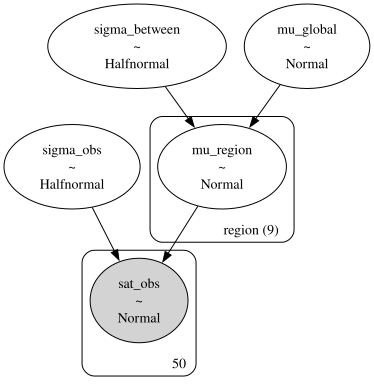

In [101]:
region_names = df["region"].cat.categories
coords = {"region": region_names}

with pm.Model(coords=coords) as hierarchical_model:
    # Hyperpriors
    mu_global = pm.Normal("mu_global", mu=df["sat"].mean(), sigma=50)
    sigma_between = pm.HalfNormal("sigma_between", sigma=100)
    
    # Group-level means (partial pooling)
    mu_region = pm.Normal("mu_region", mu=mu_global, sigma=sigma_between, dims="region")
    
    # Observation noise
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=df["sat"].std())
    
    # Likelihood
    mu_obs = mu_region[df["region"].cat.codes.values]
    sat_obs = pm.Normal("sat_obs", mu=mu_obs, sigma=sigma_obs, observed=df["sat"].values)
    
    idata_hier = pm.sample(2000, tune=1000, cores=2, target_accept=0.9, idata_kwargs={"log_likelihood": True})

pm.model_to_graphviz(hierarchical_model)

In [102]:
az.summary(idata_hier)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_global,965.3,21.8,929.6,1000.33,4490,2834,1.00,0.33,0.39
mu_region[East North Central],999.6,18,970.71,1028.52,6750,2834,1.00,0.22,0.33
mu_region[East South Central],1020.1,19.6,989.05,1050.56,5894,3139,1.00,0.26,0.33
mu_region[Middle Atlantic],899.4,23.3,861.94,936.13,7190,3190,1.00,0.27,0.43
mu_region[Mountain],988.9,14,966.81,1011.3,5670,2932,1.00,0.19,0.24
mu_region[New England],909.5,16.7,883.18,936.36,6184,2697,1.00,0.21,0.29
mu_region[Pacific],925.5,17.8,896.4,953.78,7554,2861,1.00,0.2,0.32
mu_region[South Atlantic],889.9,14.7,866.55,913.68,5399,3075,1.00,0.2,0.25
mu_region[West North Central],1067.1,16.1,1041.36,1092.57,6209,3195,1.00,0.21,0.28
mu_region[West South Central],984.6,20,953.01,1016.24,6142,2921,1.00,0.26,0.34


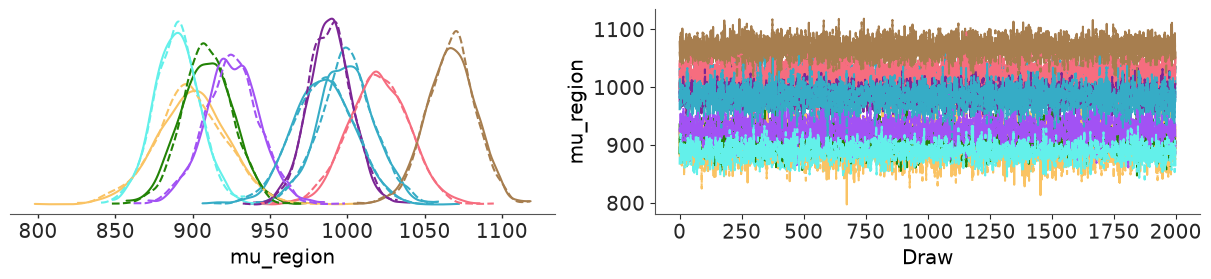

In [103]:
az.plot_trace_dist(idata_hier, var_names=["mu_region"])

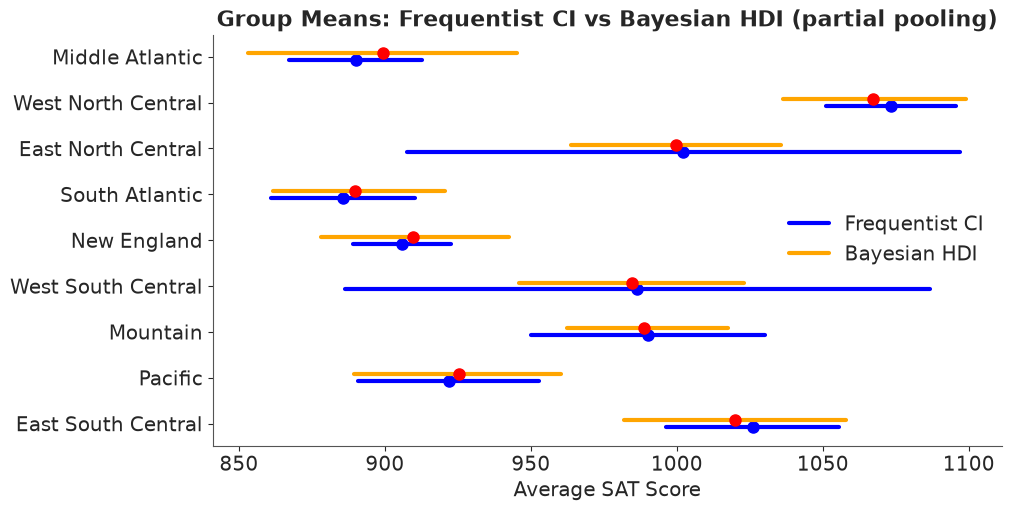

In [104]:
# Side-by-side: posterior HDI vs frequentist CI
fig, ax = plt.subplots(figsize=(10, 5))
regions = df["region"].unique()
y_pos = np.arange(len(regions))

for i, region in enumerate(regions):
    # Frequentist CI
    group = df[df["region"] == region]
    n = len(group)
    mean = group["sat"].mean()
    se = group["sat"].std(ddof=1) / np.sqrt(n)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    ax.plot([ci[0], ci[1]], [i, i], color="blue", linewidth=3, label="Frequentist CI" if i==0 else "")
    ax.plot(mean, i, "bo", markersize=8)
    
    # Bayesian HDI
    posterior = idata_hier.posterior["mu_region"].sel(region=region).values.flatten()
    hdi = az.hdi(posterior, prob=0.95)
    ax.plot([hdi[0], hdi[1]], [i+0.15, i+0.15], color="orange", linewidth=3, label="Bayesian HDI" if i==0 else "")
    ax.plot(posterior.mean(), i+0.15, "ro", markersize=8)

ax.set_yticks(y_pos + 0.075)
ax.set_yticklabels(regions)
ax.set_xlabel("Average SAT Score")
ax.legend()
plt.title("Group Means: Frequentist CI vs Bayesian HDI (partial pooling)")
plt.show()

**AI**,

* What is partial pooling? What is the opposite approach (complete pooling and no pooling)? Explain shrinkage and how it relates to partial pooling. Why does the Bayesian hierarchical model give different estimates for small regions compared to the frequentist group means
* Why does the Bayesian hierarchical model shrink estimates for small groups toward the global mean? What is the statistical reasoning behind this, and why is it generally considered better than complete pooling

### Model Comparisoinon

We create an independent model

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_region, sigma_obs]


Output()

/home/unique/Documents/applied-stats-project/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1178: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


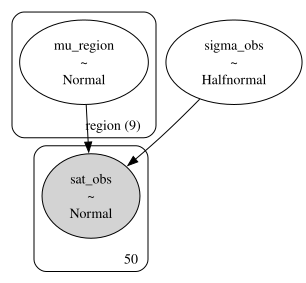

In [105]:
with pm.Model(coords=coords) as independent_model:
    mu_region = pm.Normal("mu_region", mu=df["sat"].mean(), sigma=100, dims="region")
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=df["sat"].std())
    mu_obs = mu_region[df["region"].cat.codes.values]
    sat_obs = pm.Normal("sat_obs", mu=mu_obs, sigma=sigma_obs, observed=df["sat"].values)
    idata_indep = pm.sample(2000, tune=1000, cores=2, target_accept=0.9, idata_kwargs={"log_likelihood": True})

pm.model_to_graphviz(independent_model)

/home/unique/Documents/applied-stats-project/.venv/lib/python3.14/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/unique/Documents/applied-stats-project/.venv/lib/python3.14/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  w

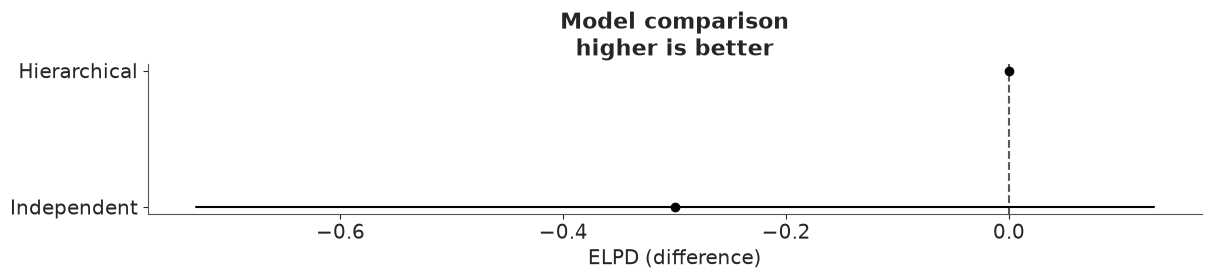

In [107]:
# LOO comparison
loo_indep = az.loo(idata_indep)
loo_hier = az.loo(idata_hier)

comparison = az.compare({"Independent": idata_indep, "Hierarchical": idata_hier})
az.plot_compare(comparison)

**AI**,

* What does the LOO comparison tell us? What does a lower LOO score mean? What does the Pareto k diagnostic tell us, and what should we do if k > 0.7 for some observations
* What is the difference between LOO and WAIC? Why was WAIC deprecated in ArviZ? What does a Pareto k > 0.7 mean and what should we do about it
* Look at our model comparison, is there a clear better model?

## 3 - MCMC Diagnostics, Funnel, Reparameterization

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,965.8,4.8,958.27,973.48,7462,5696,1.00,0.06,0.06
beta_expend,15.9,5.9,6.48,25.13,7005,5835,1.00,0.07,0.07
beta_frac,-75.1,5.9,-84.4,-65.53,6865,5888,1.00,0.07,0.07
sigma,33.31,3.54,28.2,39.27,6766,5937,1.00,0.04,0.04


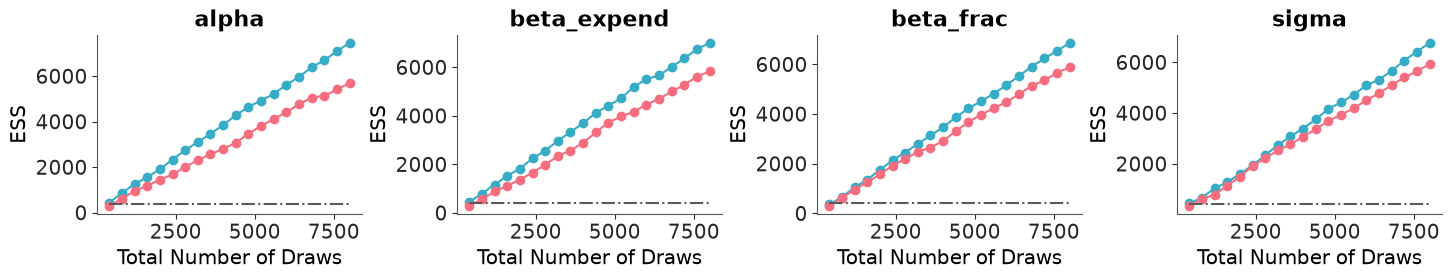

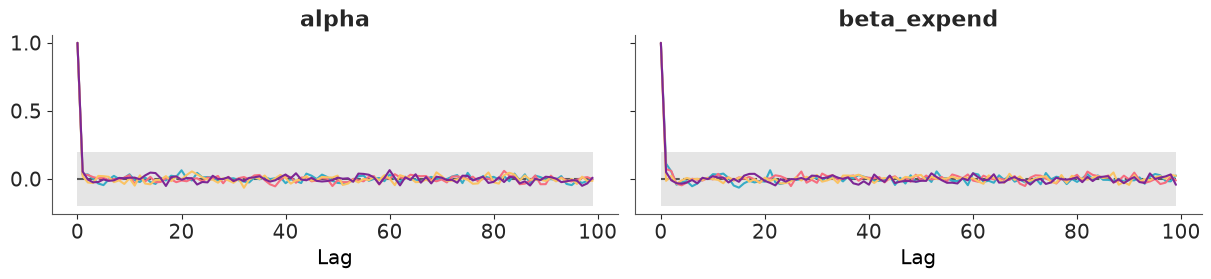

In [124]:
az.plot_ess_evolution(idata_reg, var_names=["alpha", "beta_expend", "beta_frac", "sigma"])

az.plot_autocorr(idata_reg, var_names=["alpha", "beta_expend"])

az.summary(idata_reg, var_names=["alpha", "beta_expend", "beta_frac", "sigma"])

**AI**,

* What are R-hat and ESS? What values indicate good convergence? What does a high R-hat (>1.01) indicate? What does a low ESS indicate? What are common causes of these problems?
* What are common failure modes of Metropolis-Hastings with a Gaussian proposal? What makes a proposal heuristic good? What is Hamiltonian Monte Carlo (HMC)? How does NUTS improve on HMC?
* HMC and NUTS require gradients of the log-posterior, but we're using these algorithms to estimate the posterior. How does PyMC calculate these gradients? Explain using the regression example.
* What happens if a model has discrete parameters? How does PyMC generate MCMC samples in that case?

In [116]:
# Classic Neal's funnel
with pm.Model() as funnel:
    v = pm.Normal("v", mu=0, sigma=3)
    x = pm.Normal("x", mu=0, sigma=pm.math.exp(v / 2))
    
    idata_funnel = pm.sample(2000, tune=1000, cores=2, target_accept=0.8)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [v, x]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.
There were 338 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Divergences: 338


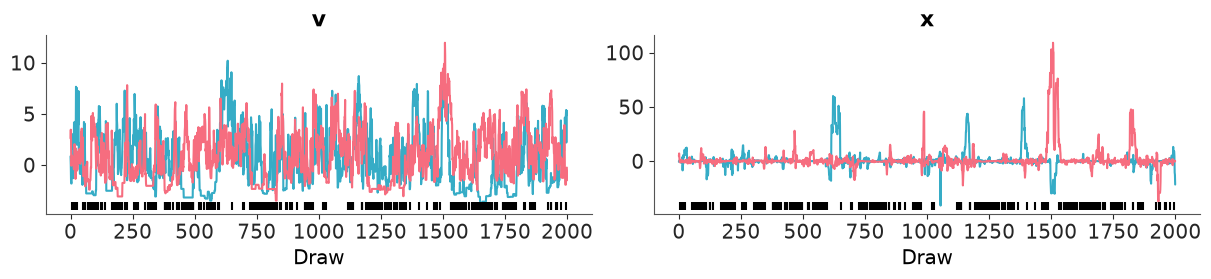

In [117]:
# Check for divergences
print(f"Divergences: {idata_funnel.sample_stats['diverging'].sum().item()}")
az.summary(idata_funnel)
az.plot_trace(idata_funnel)
plt.show()

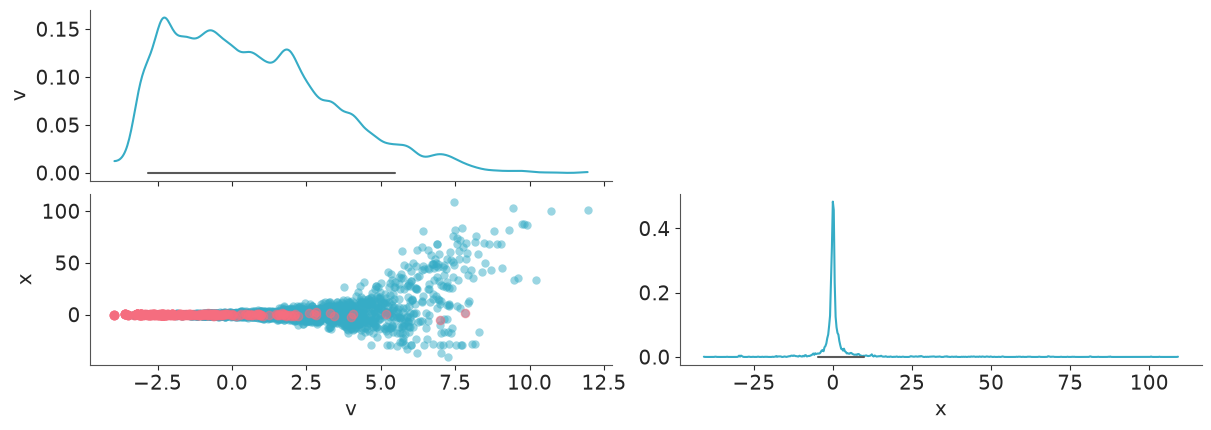

In [119]:
az.plot_pair(idata_funnel, visuals={"divergence": True, "credible_interval": True})

**AI**,

* What is Neal's funnel? Why is it difficult for HMC/NUTS to sample? What does the funnel geometry look like and why does it cause divergences?

A Fix:
$$
\begin{align}
 v &\sim \mathcal{N}\left(0, 3\right) \\
 x_\mathrm{std} &\sim \mathcal{N}\left(0,1\right) \\
 x &= \exp\left(\frac{v}{2}\right) \cdot x_\mathrm{std}
\end{align}
$$

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [v, x_std]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


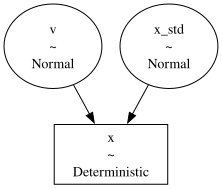

In [120]:
# Non-centered parameterization — the fix
with pm.Model() as funnel_nc:
    v = pm.Normal("v", mu=0, sigma=3)
    x_std = pm.Normal("x_std", mu=0, sigma=1)
    x = pm.Deterministic("x", pm.math.exp(v / 2) * x_std)
    
    idata_funnel_nc = pm.sample(2000, tune=1000, cores=2, target_accept=0.9)

pm.model_to_graphviz(funnel_nc)

Divergences (centered): 338
Divergences (non-centered): 0


/tmp/ipykernel_27869/1090131910.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


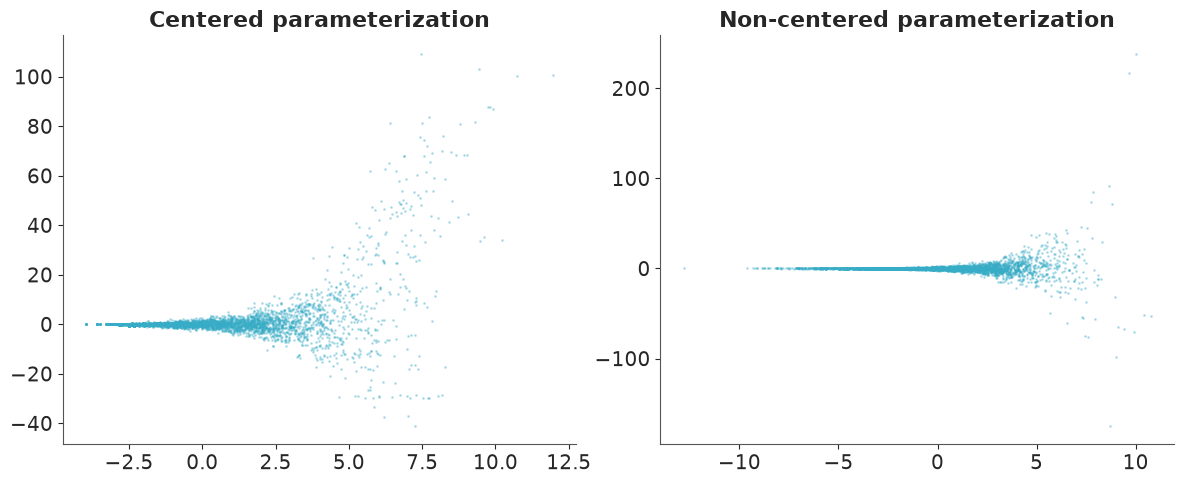

In [121]:
# Compare
print(f"Divergences (centered): {idata_funnel.sample_stats['diverging'].sum().item()}")
print(f"Divergences (non-centered): {idata_funnel_nc.sample_stats['diverging'].sum().item()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(
    idata_funnel.posterior["v"].values.flatten(),
    idata_funnel.posterior["x"].values.flatten(),
    alpha=0.3, s=1, label="Centered"
)
axes[1].scatter(
    idata_funnel_nc.posterior["v"].values.flatten(),
    idata_funnel_nc.posterior["x"].values.flatten(),
    alpha=0.3, s=1, label="Non-centered"
)
axes[0].set_title("Centered parameterization")
axes[1].set_title("Non-centered parameterization")
plt.tight_layout()
plt.show()

**AI**,

* What is the non-centered parameterization and why does it fix Neal's funnel? Explain the reparameterization trick mathematically. Why does the non-centered version have better geometry for HMC?
* When should you use a centered vs non-centered parameterization? Are there cases where non-centered is worse than centered?